# Isaiah Mposhomali: Probability of Default (PD) Project

## Overview

**Probability of Default (PD)** — the likelihood that a borrower will fail to repay a loan , using demographic, employment and loan‑related characteristics.

**Target variable:** `loan_status` (`1` = defaulted, `0` = repaid)

## Workflow

1. Load & explore the data
2. Clean the data (remove unrealistic values, impute missing values)
3. Encode categorical features & scale numeric ones
4. Split into train/test, then balance the **training set only** with SMOTE
5. Train Logistic Regression, Random Forest and XGBoost
6. Evaluate & compare the three models
7. Interpret results (feature importance, risk deciles)
8. Save models for reuse and demonstrate scoring a new applicant

## 1. Libraries

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. Load Data


In [22]:
credit_risk = pd.read_csv("C:/Users/mposh/Desktop/Projects 2026/Credit Risk Project/Credit-Risk-CR-Modeling-Project/notebooks/credit_risk_dataset1.csv")
print(f"Shape: {credit_risk.shape[0]:,} rows x {credit_risk.shape[1]} columns")
credit_risk.head()

Shape: 32,581 rows x 12 columns


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [23]:
credit_risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [24]:
credit_risk.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_status,32581.0,0.218164,0.413006,0.00,0.00,0.00,0.00,1.00
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


In [25]:
credit_risk_copy = credit_risk.copy()  # keep an untouched copy of the raw data

## 3. Exploratory Data Analysis (EDA)

Before cleaning anything, we look at:
- how imbalanced the target is
- missing values
- distributions of the numeric features (to spot unrealistic outliers)
- how each feature relates to default risk
- relationships between categorical features and default

Columns with missing values:
loan_int_rate        3116
person_emp_length     895
dtype: int64


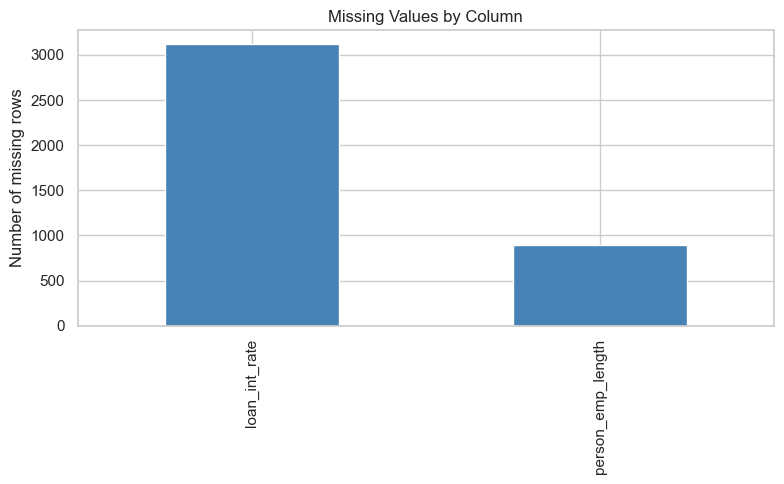

In [27]:
missing = credit_risk.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

ax = missing.plot(kind="bar", color="steelblue")
ax.set_ylabel("Number of missing rows")
ax.set_title("Missing Values by Column")
plt.tight_layout()
plt.show()

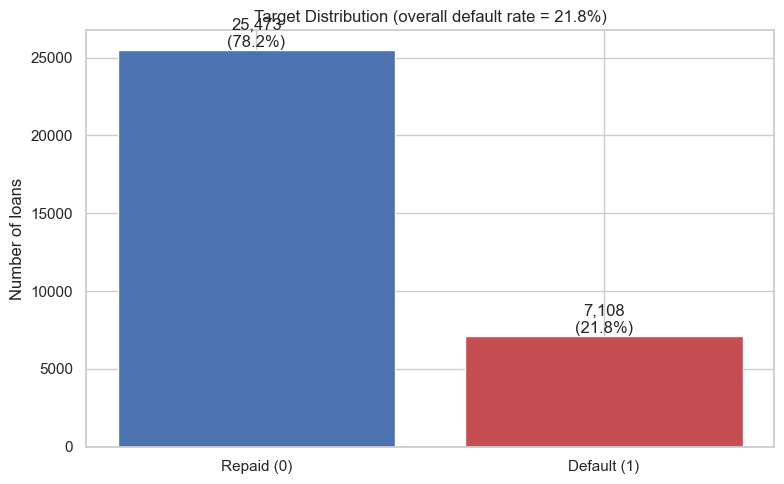

In [28]:
default_rate = credit_risk['loan_status'].mean()
counts = credit_risk['loan_status'].value_counts().sort_index()

fig, ax = plt.subplots()
bars = ax.bar(['Repaid (0)', 'Default (1)'], counts.values, color=['#4C72B0', '#C44E52'])
for bar, count in zip(bars, counts.values):
    ax.annotate(f"{count:,}\n({count/len(credit_risk):.1%})",
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom')
ax.set_title(f"Target Distribution (overall default rate = {default_rate:.1%})")
ax.set_ylabel("Number of loans")
plt.tight_layout()
plt.show()

The dataset is **imbalanced**: only about a quarter of loans defaulted. 

This is why we will apply SMOTE later — but only to the training data, so the test set still reflects the real-world class balance.

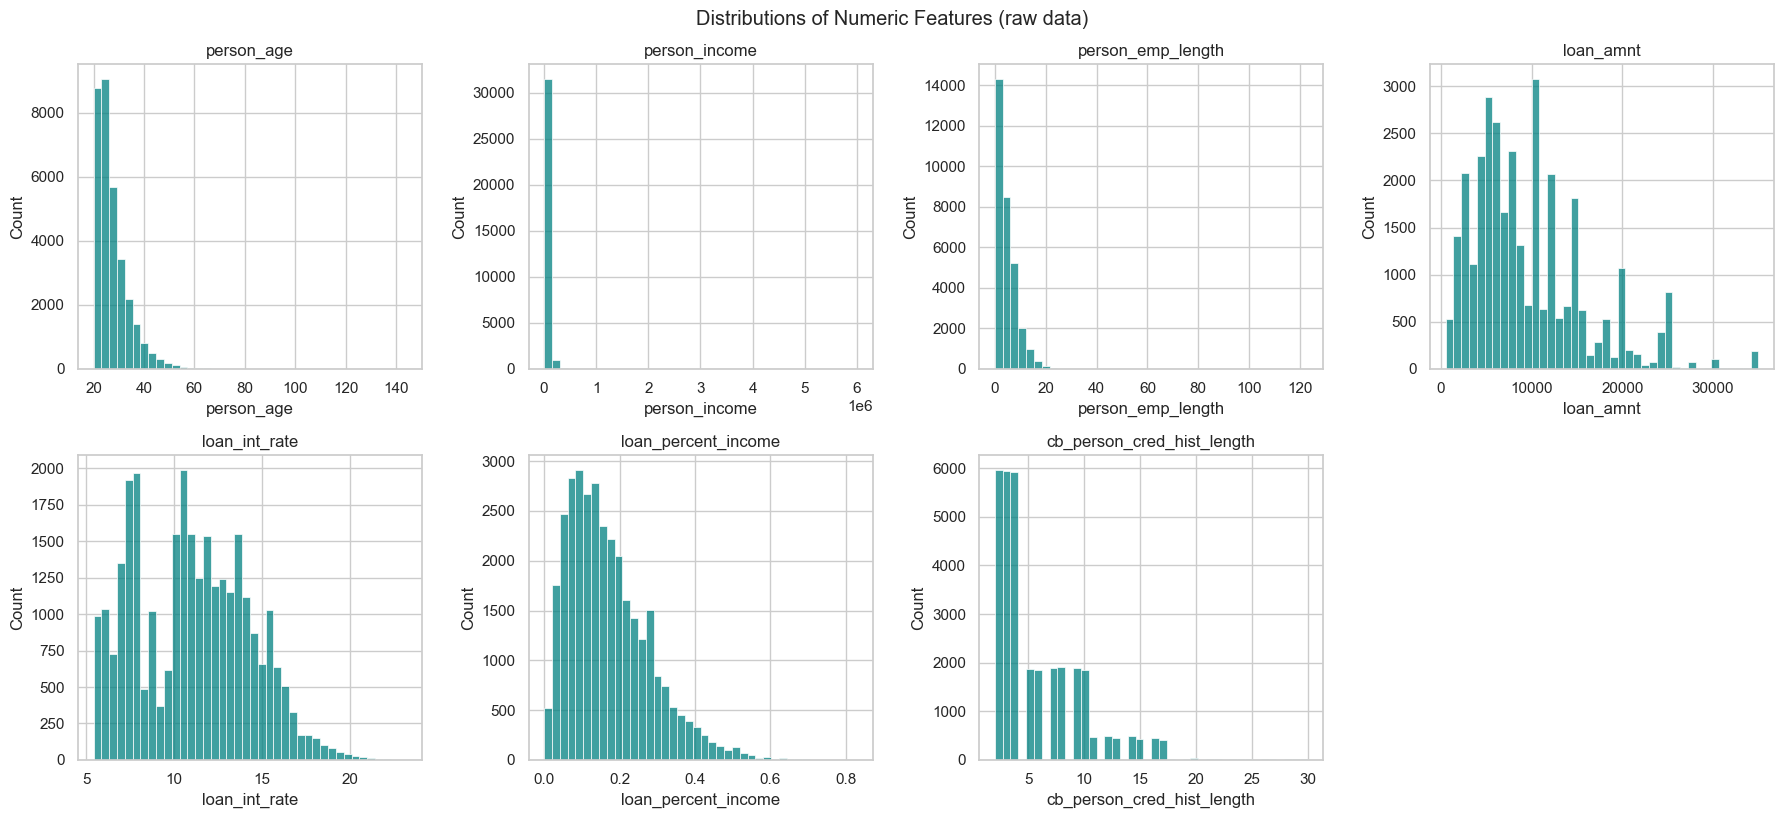

In [29]:
numeric_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(credit_risk[col].dropna(), bins=40, ax=axes[i], color="teal")
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.suptitle("Distributions of Numeric Features (raw data)", y=1.02)
plt.show()

Two columns show clearly unrealistic outliers:

- **`person_age`** has values well beyond 100.
- **`person_emp_length`** (years employed) has values above 40, which is implausible alongside the observed ages.

Let's confirm with explicit checks before deciding on cut-offs.

In [30]:
print("Top 10 oldest ages:")
print(sorted(credit_risk['person_age'].unique())[-10:])

print("\nTop 10 longest employment lengths (years):")
print(sorted(credit_risk['person_emp_length'].dropna().unique())[-10:])

Top 10 oldest ages:
[np.int64(69), np.int64(70), np.int64(73), np.int64(76), np.int64(78), np.int64(80), np.int64(84), np.int64(94), np.int64(123), np.int64(144)]

Top 10 longest employment lengths (years):
[np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(34.0), np.float64(38.0), np.float64(41.0), np.float64(123.0)]


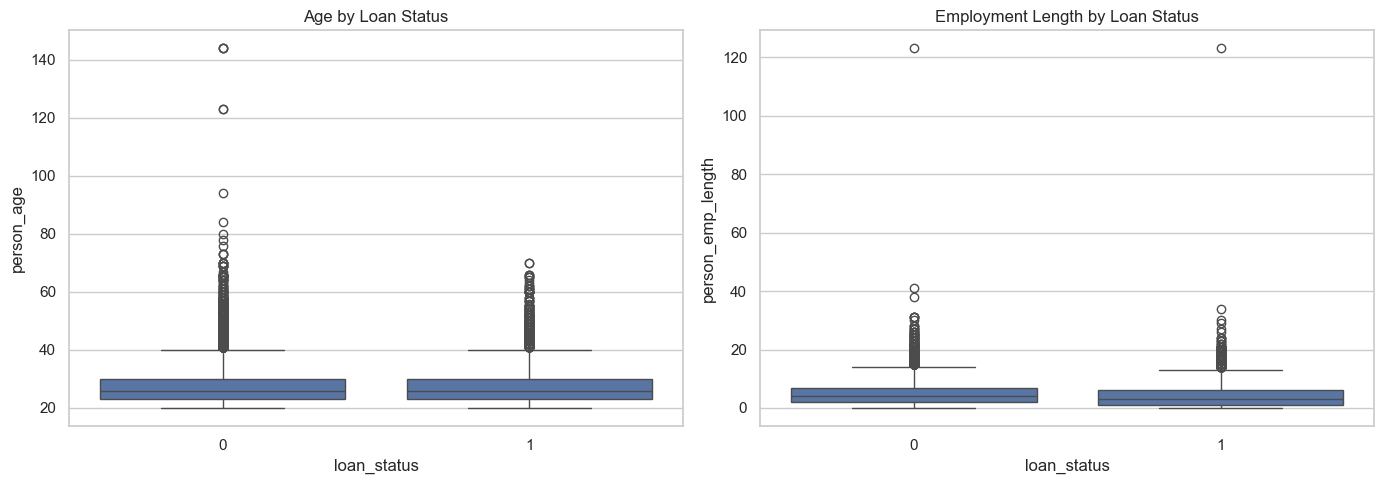

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x=credit_risk['loan_status'], y=credit_risk['person_age'], ax=axes[0])
axes[0].set_title("Age by Loan Status")
sns.boxplot(x=credit_risk['loan_status'], y=credit_risk['person_emp_length'], ax=axes[1])
axes[1].set_title("Employment Length by Loan Status")
plt.tight_layout()
plt.show()

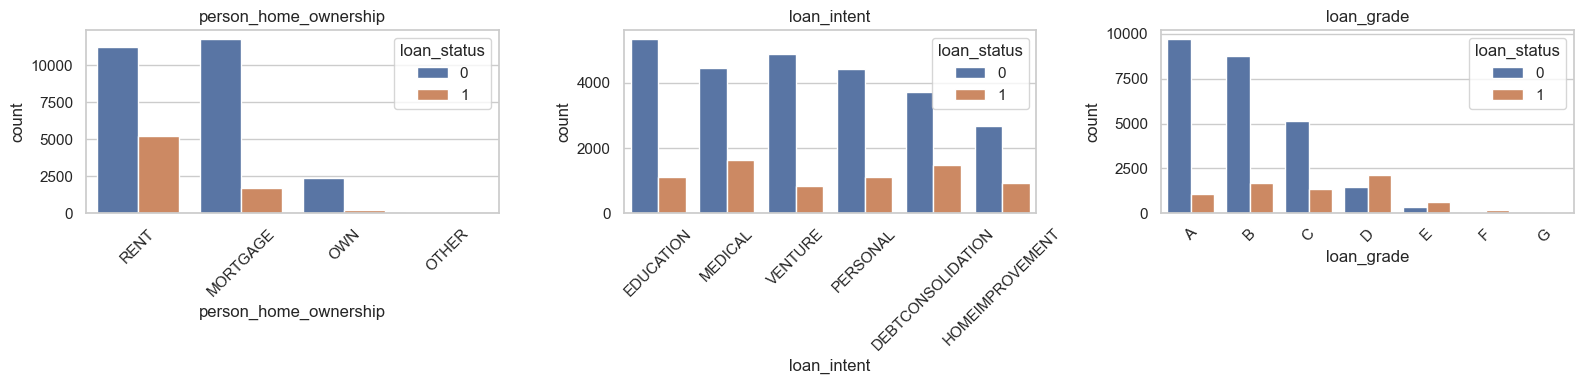

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['person_home_ownership', 'loan_intent', 'loan_grade']):
    order = credit_risk[col].value_counts().index
    sns.countplot(data=credit_risk, x=col, order=order, hue='loan_status', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

`loan_grade` (A→G) clearly tracks default risk , later grades default far more often. This is why we will **keep it as an ordinal feature** rather than dropping it.

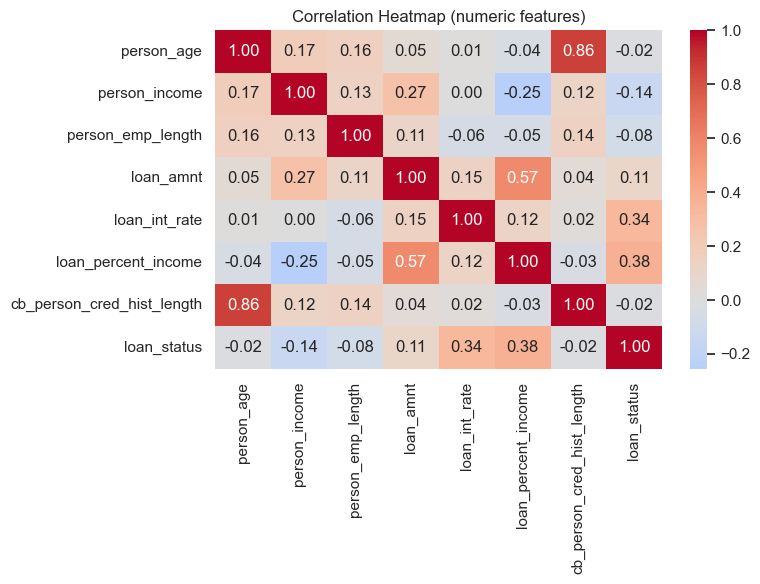

In [33]:
corr = credit_risk[numeric_cols + ['loan_status']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric features)")
plt.tight_layout()
plt.show()

## 4. Data Cleaning

Based on the EDA above, we will:

1. Remove records with `person_age > 70` (data-entry errors — no other borrower is over ~70 and a handful of rows have ages of 120+).
2. Remove records with `person_emp_length > 47` (implausible given the age distribution).
3. Impute the missing `loan_int_rate` values with the **median** (robust to the right-skew visible in the histogram above).
4. Check for duplicate rows.

In [34]:
n_before = len(credit_risk)
cr_clean = credit_risk[credit_risk['person_age'] <= 70].copy()
print(f"Removed {n_before - len(cr_clean)} rows with person_age > 70")

Removed 13 rows with person_age > 70


In [35]:
n_before = len(cr_clean)
cr_clean = cr_clean[cr_clean['person_emp_length'] <= 47].copy()
cr_clean.reset_index(drop=True, inplace=True)
print(f"Removed {n_before - len(cr_clean)} rows with person_emp_length > 47")
print(f"Remaining rows: {len(cr_clean):,}")

Removed 897 rows with person_emp_length > 47
Remaining rows: 31,671


In [36]:
median_rate = cr_clean['loan_int_rate'].median()
n_missing = cr_clean['loan_int_rate'].isnull().sum()
cr_clean['loan_int_rate'] = cr_clean['loan_int_rate'].fillna(median_rate)
print(f"Imputed {n_missing} missing loan_int_rate values with the median ({median_rate:.2f}%)")

print("\nRemaining missing values:")
print(cr_clean.isnull().sum().sum())

Imputed 3045 missing loan_int_rate values with the median (10.99%)

Remaining missing values:
0


In [37]:
n_dupes = cr_clean.duplicated().sum()
cr_clean = cr_clean.drop_duplicates().reset_index(drop=True)
print(f"Removed {n_dupes} duplicate rows. Final shape: {cr_clean.shape}")

Removed 157 duplicate rows. Final shape: (31514, 12)


In [38]:
cr_data = cr_clean.copy()
cr_data.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,31514.0,27.729549,6.164949,20.00,23.00,26.00,30.00,70.00
person_income,31514.0,66503.904328,52757.515256,4000.00,39438.00,56000.00,80000.00,2039784.00
person_emp_length,31514.0,4.781494,4.031086,0.00,2.00,4.00,7.00,38.00
loan_amnt,31514.0,9664.450720,6335.145239,500.00,5000.00,8000.00,12500.00,35000.00
loan_int_rate,31514.0,11.040255,3.071946,5.42,8.49,10.99,13.16,23.22
loan_status,31514.0,0.215999,0.411520,0.00,0.00,0.00,0.00,1.00
loan_percent_income,31514.0,0.169669,0.106302,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,31514.0,5.811258,4.052653,2.00,3.00,4.00,8.00,30.00


## 5. Feature Encoding

- **`loan_grade`** (A → G) is ordinal risk information, so we map it to integers `0–6` instead of dropping it.
- **`cb_person_default_on_file`** is binary (`Y`/`N`) → mapped to `1`/`0`.
- **`person_home_ownership`** and **`loan_intent`** are nominal categories with no natural order → one-hot encoded (dropping the first category to avoid multicollinearity).

In [39]:
grade_order = sorted(cr_data['loan_grade'].unique())
grade_map = {g: i for i, g in enumerate(grade_order)}
print("loan_grade encoding:", grade_map)

cr_encoded = cr_data.copy()
cr_encoded['loan_grade_ord'] = cr_encoded['loan_grade'].map(grade_map)
cr_encoded['cb_person_default_on_file_bin'] = np.where(
    cr_encoded['cb_person_default_on_file'] == 'Y', 1, 0
)

home_ownership_dummies = pd.get_dummies(
    cr_encoded['person_home_ownership'], prefix='home', drop_first=True
).astype(int)
loan_intent_dummies = pd.get_dummies(
    cr_encoded['loan_intent'], prefix='intent', drop_first=True
).astype(int)

home_ownership_dummies.head()

loan_grade encoding: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}


,home_OTHER,home_OWN,home_RENT
0,0,1,0
1,0,0,0
2,0,0,1
3,0,0,1
4,0,1,0


## 6. Feature Scaling

Logistic Regression's coefficients (and its optimiser) are sensitive to feature scale, so we standardise the numeric columns. Tree-based models (Random Forest, XGBoost) are scale-invariant, but applying the same scaled features to all three models keeps the pipeline simple and doesn't hurt them.

In [40]:
numeric_feature_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
                        'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
                        'loan_grade_ord']

scaler = StandardScaler()
scaled_numeric = pd.DataFrame(
    scaler.fit_transform(cr_encoded[numeric_feature_cols]),
    columns=numeric_feature_cols,
    index=cr_encoded.index
)

features = pd.concat(
    [scaled_numeric, home_ownership_dummies, loan_intent_dummies,
     cr_encoded['cb_person_default_on_file_bin'].rename('cb_default_on_file')],
    axis=1
)
target = cr_encoded['loan_status']

print(f"Feature matrix shape: {features.shape}")
features.head()

Feature matrix shape: (31514, 17)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_grade_ord,home_OTHER,home_OWN,home_RENT,intent_EDUCATION,intent_HOMEIMPROVEMENT,intent_MEDICAL,intent_PERSONAL,intent_VENTURE,cb_default_on_file
0,-1.09160,-1.078610,0.054206,-1.367702,0.032470,-0.655398,-0.940450,-0.195970,0,1,0,1,0,0,0,0,0
1,-0.44276,-1.078610,-0.938098,-0.657367,0.595640,3.766056,-0.693695,0.659402,0,0,0,0,0,1,0,0,0
2,-0.76718,-0.019029,-0.193870,3.999269,1.363895,3.389762,-0.940450,0.659402,0,0,1,0,0,1,0,0,0
3,-0.60497,-0.229429,0.798434,3.999269,1.051384,3.577909,-0.446939,0.659402,0,0,1,0,0,1,0,0,1
4,-1.09160,-1.072924,-0.690022,-1.130923,-1.269657,0.755704,-0.940450,-1.051341,0,1,0,0,0,0,0,1,0


## 7. Train / Test Split
SMOTE creates synthetic rows by interpolating between real neighbours, that order lets information from the synthetic training rows leak into the test set (and vice-versa), which **inflates test accuracy**.

1. Split raw data into train/test first.
2. Fit SMOTE **only on the training set**.
3. Leave the test set at its natural (imbalanced) class distribution.

In [41]:
x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.20, random_state=RANDOM_STATE, stratify=target
)

print("Train shape:", x_train.shape, " | Test shape:", x_test.shape)
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance (kept realistic — NOT balanced):")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (25211, 17)  | Test shape: (6303, 17)

Train class balance:
loan_status
0    0.784
1    0.216
Name: proportion, dtype: float64

Test class balance (kept realistic — NOT balanced):
loan_status
0    0.784
1    0.216
Name: proportion, dtype: float64


## 8. Handle Class Imbalance with SMOTE (Training Set Only)

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic default examples by interpolating between existing minority-class (default) neighbours, so the model sees a balanced 50/50 training set and doesn't simply learn to predict "no default" every time.

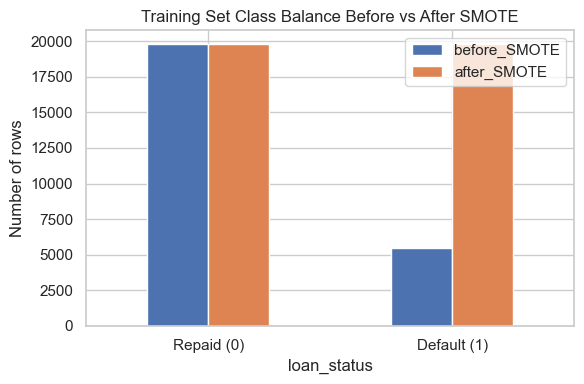

,before_SMOTE,after_SMOTE
loan_status,,
0,19765,19765
1,5446,19765


In [42]:
smote = SMOTE(random_state=RANDOM_STATE)
x_train_bal, y_train_bal = smote.fit_resample(x_train, y_train)

before_after = pd.DataFrame({
    'before_SMOTE': y_train.value_counts().sort_index(),
    'after_SMOTE': y_train_bal.value_counts().sort_index()
})
before_after.plot(kind='bar', figsize=(6, 4))
plt.title("Training Set Class Balance Before vs After SMOTE")
plt.xticks([0, 1], ['Repaid (0)', 'Default (1)'], rotation=0)
plt.ylabel("Number of rows")
plt.tight_layout()
plt.show()

before_after

## 9. Model Training & Evaluation Framework

Rather than repeating the same evaluation code three times, we define one reusable function that, for any fitted model, prints a classification report and plots:

- a **confusion matrix**
- an **ROC curve** with AUC
- the **KS (Kolmogorov–Smirnov) statistic** — the maximum separation between the cumulative distributions of predicted scores for defaulters vs non-defaulters. It's a standard credit-risk metric: the higher the KS, the better the model separates good and bad borrowers.

It returns a small dictionary of headline metrics so we can compare models later.

In [43]:
def ks_statistic(y_true, y_proba):
    """Kolmogorov-Smirnov statistic between the score distributions of the two classes."""
    df = pd.DataFrame({'y': y_true, 'p': y_proba}).sort_values('p')
    df['cum_good'] = (df['y'] == 0).cumsum() / (df['y'] == 0).sum()
    df['cum_bad'] = (df['y'] == 1).cumsum() / (df['y'] == 1).sum()
    return np.max(np.abs(df['cum_good'] - df['cum_bad']))


def evaluate_model(model, x_test, y_test, model_name):
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    print(f"===== {model_name} =====")
    print(classification_report(y_test, y_pred, target_names=['Repaid', 'Default']))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Repaid', 'Default'], yticklabels=['Repaid', 'Default'], ax=axes[0])
    axes[0].set_title(f"{model_name} — Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='darkorange')
    axes[1].plot([0, 1], [0, 1], linestyle='--', color='grey')
    axes[1].set_title(f"{model_name} — ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    ks = ks_statistic(y_test.values, y_proba)
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'auc': auc,
        'ks': ks,
    }
    print(f"KS statistic: {ks:.3f}\n")
    return metrics, y_proba


results = {}
probas = {}

## 10. Logistic Regression

Probability of Default (PD) is the likelihood that a borrower will fail to repay a loan, expressed as a value between **0 and 1**:

- **1** → default
- **0** → non-default

Logistic Regression models this directly: it fits a linear combination of the features and squashes it through the sigmoid function so the output is a valid probability. Its coefficients are easy to interpret — a positive coefficient means the feature *increases* the odds of default, and a negative coefficient *decreases* them.

In [44]:
logit = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logit.fit(x_train_bal, y_train_bal)

with open(MODELS_DIR / "logistic_pd_model.pkl", "wb") as f:
    pickle.dump(logit, f)

print(f"Training accuracy: {logit.score(x_train_bal, y_train_bal):.3f}")

Training accuracy: 0.795


===== Logistic Regression =====
              precision    recall  f1-score   support

      Repaid       0.93      0.81      0.87      4942
     Default       0.53      0.78      0.63      1361

    accuracy                           0.80      6303
   macro avg       0.73      0.80      0.75      6303
weighted avg       0.84      0.80      0.82      6303



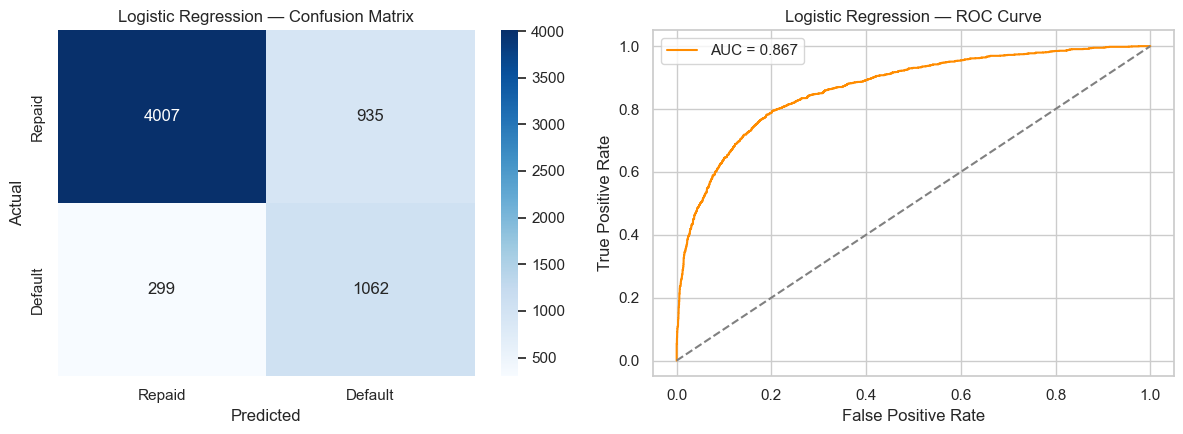

KS statistic: 0.592



In [45]:
results['Logistic Regression'], probas['Logistic Regression'] = evaluate_model(
    logit, x_test, y_test, "Logistic Regression"
)

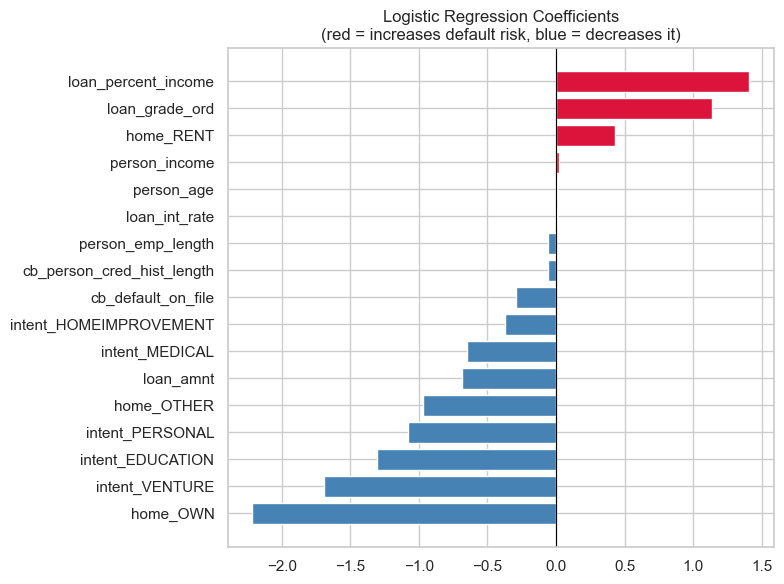

In [46]:
logit_importance = pd.DataFrame({
    'feature': x_train_bal.columns,
    'coefficient': logit.coef_[0]
}).sort_values('coefficient')

plt.figure(figsize=(8, 6))
colors = ['crimson' if c > 0 else 'steelblue' for c in logit_importance['coefficient']]
plt.barh(logit_importance['feature'], logit_importance['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Logistic Regression Coefficients\n(red = increases default risk, blue = decreases it)")
plt.tight_layout()
plt.show()

Coefficients confirm intuition from the EDA: a higher `loan_percent_income`, higher interest rate, and higher `loan_grade_ord` (worse grade) push the odds of default up, while higher income and longer credit history pull it down.

## 11. Random Forest

Random Forest builds many decision trees on bootstrapped samples of the data and averages their votes. It naturally captures non-linear relationships and interactions between features (e.g. how income *and* loan amount jointly affect risk) without needing them to be specified manually.

In [47]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(x_train_bal, y_train_bal)

with open(MODELS_DIR / "random_forest_pd_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print(f"Training accuracy: {rf.score(x_train_bal, y_train_bal):.3f}")

Training accuracy: 1.000


===== Random Forest =====
              precision    recall  f1-score   support

      Repaid       0.93      0.98      0.96      4942
     Default       0.92      0.74      0.82      1361

    accuracy                           0.93      6303
   macro avg       0.93      0.86      0.89      6303
weighted avg       0.93      0.93      0.93      6303



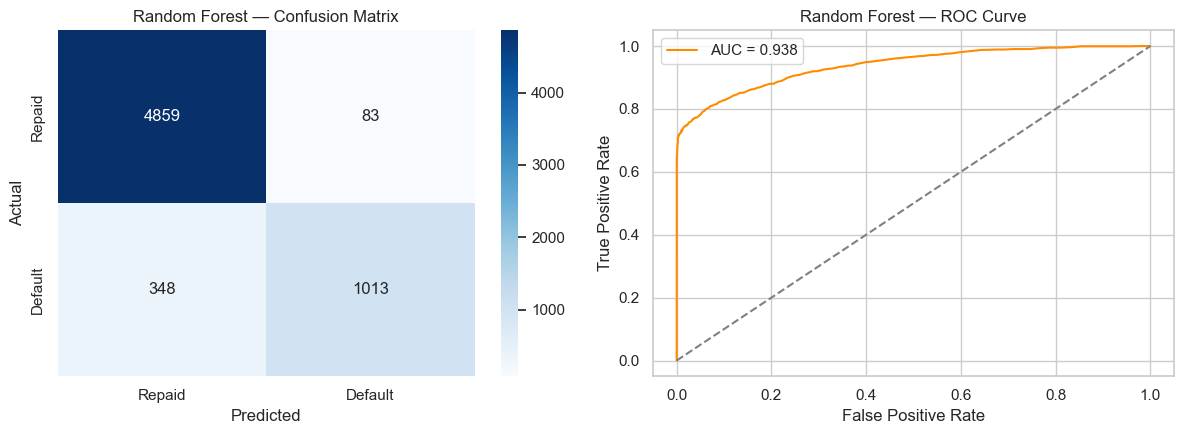

KS statistic: 0.738



In [48]:
results['Random Forest'], probas['Random Forest'] = evaluate_model(
    rf, x_test, y_test, "Random Forest"
)

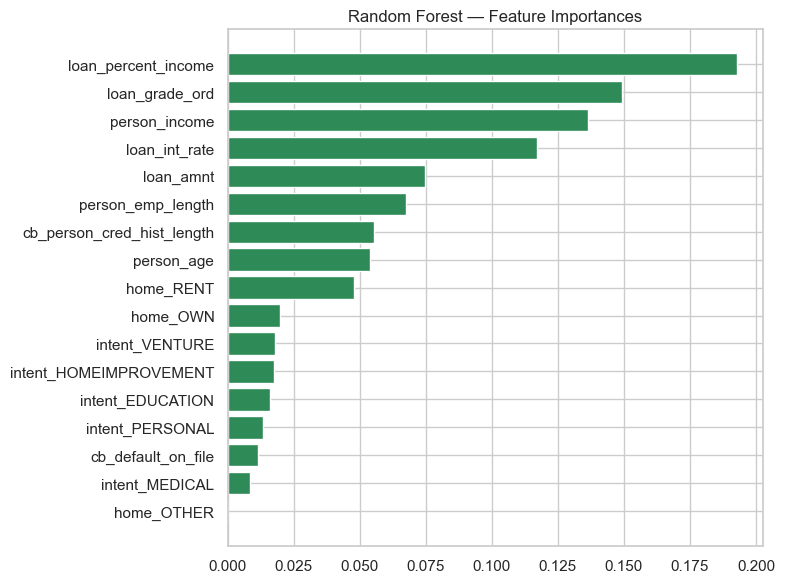

In [49]:
rf_importance = pd.DataFrame({
    'feature': x_train_bal.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(rf_importance['feature'], rf_importance['importance'], color='seagreen')
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()

## 12. XGBoost

XGBoost is a gradient-boosted tree ensemble: each new tree is trained to correct the errors of the previous ones. It's usually the strongest of the three on tabular data like this, though it's more prone to overfitting without tuning, which is why we compare it against the simpler models rather than assuming it wins by default.

In [50]:
xgb_model = XGBClassifier(
    tree_method='hist', random_state=RANDOM_STATE, eval_metric='logloss'
)
xgb_model.fit(x_train_bal, y_train_bal)

with open(MODELS_DIR / "xgboost_pd_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

print(f"Training accuracy: {xgb_model.score(x_train_bal, y_train_bal):.3f}")

Training accuracy: 0.969


===== XGBoost =====
              precision    recall  f1-score   support

      Repaid       0.94      0.99      0.96      4942
     Default       0.94      0.75      0.84      1361

    accuracy                           0.94      6303
   macro avg       0.94      0.87      0.90      6303
weighted avg       0.94      0.94      0.93      6303



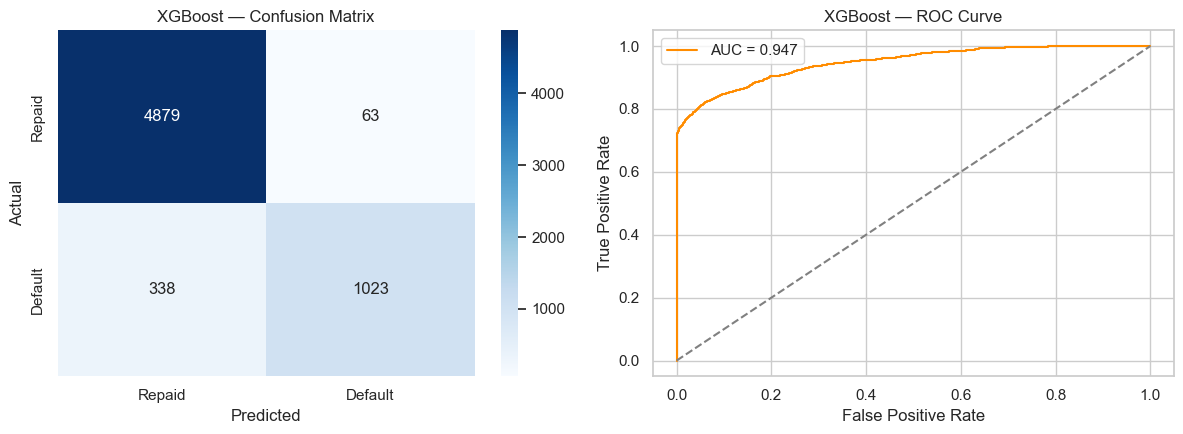

KS statistic: 0.761



In [51]:
results['XGBoost'], probas['XGBoost'] = evaluate_model(
    xgb_model, x_test, y_test, "XGBoost"
)

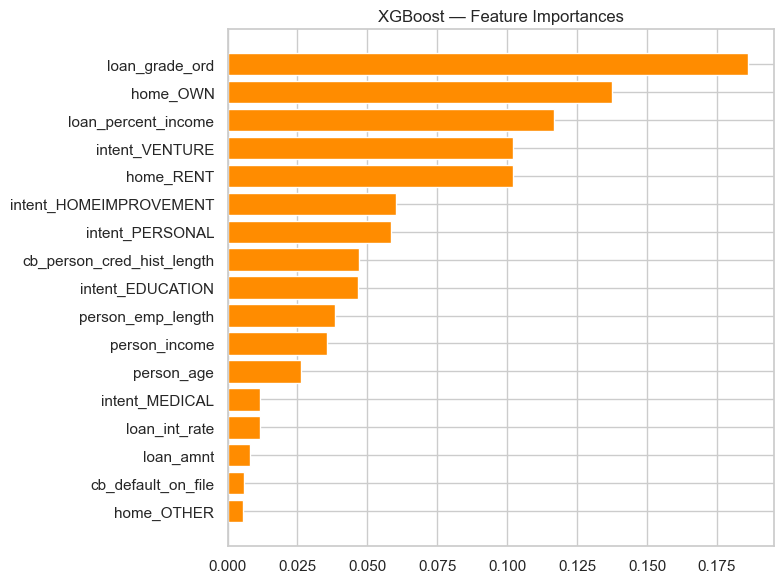

In [52]:
xgb_importance = pd.DataFrame({
    'feature': x_train_bal.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(xgb_importance['feature'], xgb_importance['importance'], color='darkorange')
plt.title("XGBoost — Feature Importances")
plt.tight_layout()
plt.show()

## 13. Model Comparison

Now that all three models have been evaluated the same way, we can compare them side by side on accuracy, precision, recall, F1, AUC and KS — and overlay their ROC curves on one chart.

In [53]:
comparison_df = pd.DataFrame(results.values()).set_index('model').round(3)
comparison_df

,accuracy,precision,recall,f1,auc,ks
model,,,,,,
Logistic Regression,0.804,0.532,0.780,0.633,0.867,0.592
Random Forest,0.932,0.924,0.744,0.825,0.938,0.738
XGBoost,0.936,0.942,0.752,0.836,0.947,0.761


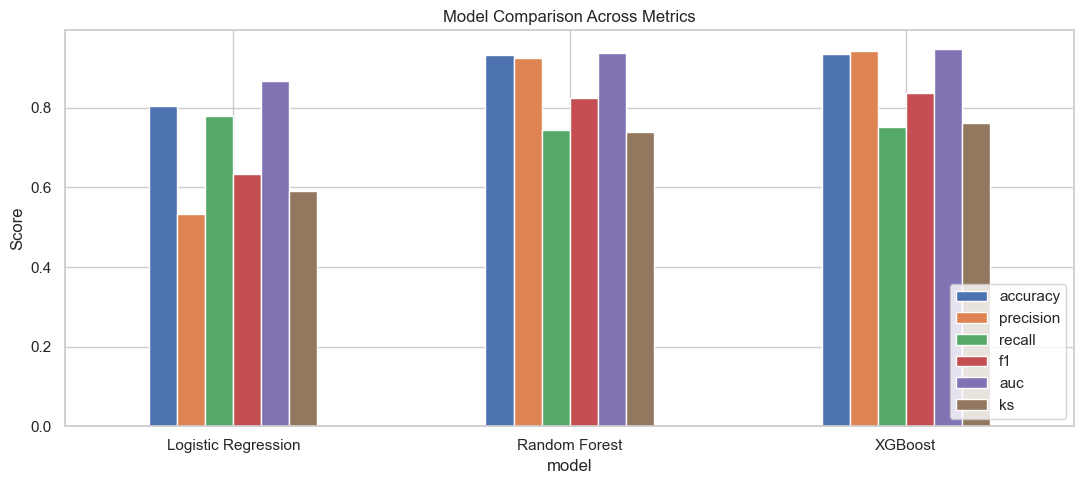

In [54]:
comparison_df[['accuracy', 'precision', 'recall', 'f1', 'auc', 'ks']].plot(
    kind='bar', figsize=(11, 5)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

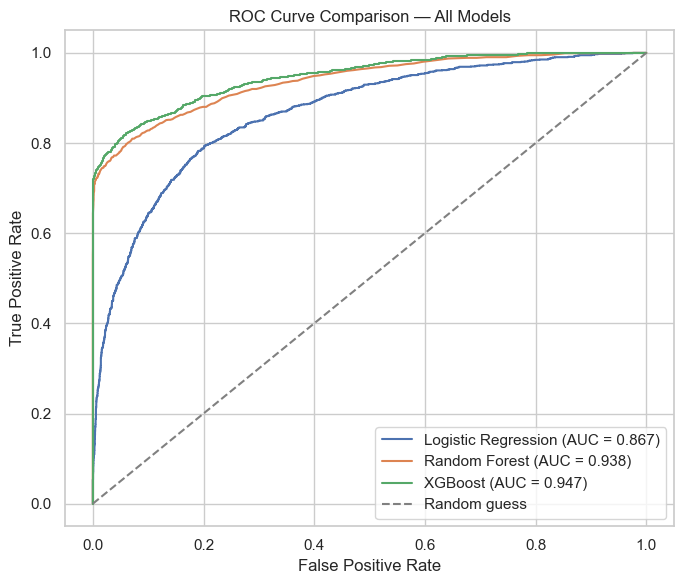

In [55]:
plt.figure(figsize=(7, 6))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
feature_importance_combined = (
    logit_importance.rename(columns={'coefficient': 'logistic_coef'})
    .merge(rf_importance.rename(columns={'importance': 'rf_importance'}), on='feature')
    .merge(xgb_importance.rename(columns={'importance': 'xgb_importance'}), on='feature')
    .sort_values('xgb_importance', ascending=False)
    .reset_index(drop=True)
)
feature_importance_combined

,feature,logistic_coef,rf_importance,xgb_importance
0,loan_grade_ord,1.134842,0.149377,0.186093
1,home_OWN,-2.213813,0.019720,0.137382
2,loan_percent_income,1.407618,0.192843,0.116841
3,intent_VENTURE,-1.691211,0.017904,0.102210
4,home_RENT,0.431539,0.047820,0.102085
5,intent_HOMEIMPROVEMENT,-0.369206,0.017656,0.060376
6,intent_PERSONAL,-1.078092,0.013304,0.058515
7,cb_person_cred_hist_length,-0.058641,0.055336,0.046908
8,intent_EDUCATION,-1.306668,0.015966,0.046520
9,person_emp_length,-0.056643,0.067499,0.038395


**Reading the comparison:** the tree-based models (Random Forest, XGBoost) typically edge out Logistic Regression on AUC/KS because they capture non-linear effects, but Logistic Regression remains the most interpretable and is often preferred by regulators for credit decisions. In practice, a common approach is to use a tree-based model for the strongest possible ranking of risk, and a logistic model (or its coefficients) to *explain* decisions to regulators or customers.

## 14. Business Interpretation: Risk Deciles (Gains Chart)

A PD model's real job is to **rank** borrowers by risk so that a lender can, for example, decline the riskiest 10% of applicants. We check this by splitting the test set into 10 equal-sized groups (deciles) based on predicted default probability from our best model (highest AUC), and see how the *actual* default rate changes across deciles. A good model should show a steadily rising default rate from decile 1 (lowest risk) to decile 10 (highest risk).

In [57]:
best_model_name = comparison_df['auc'].idxmax()
print(f"Best model by AUC: {best_model_name}")

best_proba = probas[best_model_name]
decile_df = pd.DataFrame({'y_true': y_test.values, 'proba': best_proba})
decile_df['decile'] = pd.qcut(decile_df['proba'], 10, labels=False, duplicates='drop') + 1

gains = decile_df.groupby('decile').agg(
    n_loans=('y_true', 'size'),
    actual_default_rate=('y_true', 'mean'),
    avg_predicted_proba=('proba', 'mean')
).reset_index()

gains

Best model by AUC: XGBoost


,decile,n_loans,actual_default_rate,avg_predicted_proba
0,1,631,0.000000,0.000300
1,2,630,0.007937,0.003761
2,3,630,0.017460,0.017158
3,4,630,0.036508,0.034668
4,5,631,0.041204,0.056539
5,6,630,0.061905,0.086409
6,7,630,0.122222,0.135932
7,8,630,0.165079,0.234894
8,9,630,0.706349,0.737799
9,10,631,1.000000,0.994839


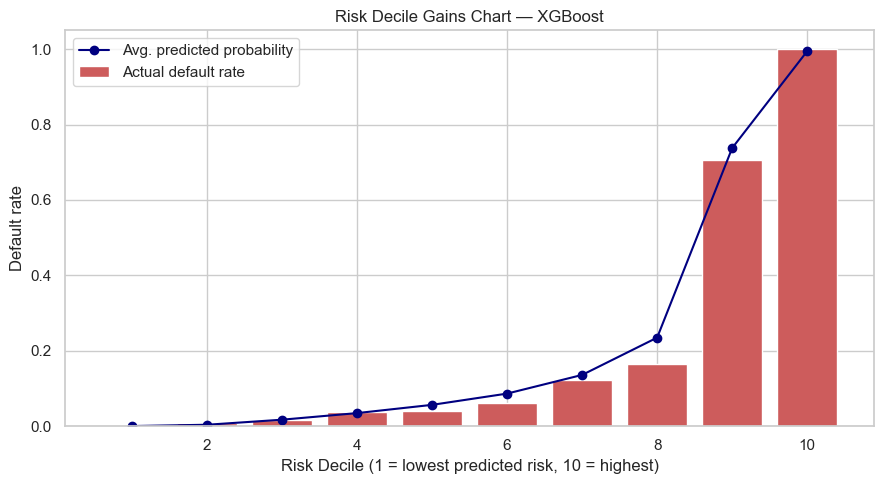

In [58]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(gains['decile'], gains['actual_default_rate'], color='indianred', label='Actual default rate')
ax.plot(gains['decile'], gains['avg_predicted_proba'], color='navy', marker='o', label='Avg. predicted probability')
ax.set_xlabel("Risk Decile (1 = lowest predicted risk, 10 = highest)")
ax.set_ylabel("Default rate")
ax.set_title(f"Risk Decile Gains Chart — {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

A steadily increasing bar chart from decile 1 to decile 10 confirms the model is doing its core job: sorting borrowers from safest to riskiest, which is what supports real decisions like risk-based pricing or setting an approval cut-off.

## 15. Export Test-Set Predictions with Original Features

In [59]:
predictions_export = cr_data.loc[x_test.index].copy()
for name, proba in probas.items():
    col_prefix = name.lower().replace(' ', '_')
    predictions_export[f'{col_prefix}_proba'] = proba
    predictions_export[f'{col_prefix}_pred'] = (proba >= 0.5).astype(int)

predictions_export.to_csv("pd_predictions.csv", index=False)
print(f"Saved {len(predictions_export):,} predictions to pd_predictions.csv")
predictions_export.head()

Saved 6,303 predictions to pd_predictions.csv


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,logistic_regression_proba,logistic_regression_pred,random_forest_proba,random_forest_pred,xgboost_proba,xgboost_pred
16752,21,27600,OWN,3.0,EDUCATION,C,1000,15.27,0,0.04,Y,3,0.025905,0,0.043333,0,0.001139,0
25874,27,37440,RENT,5.0,PERSONAL,A,15000,7.90,1,0.40,N,8,0.679465,1,0.996667,1,0.996275,1
22567,33,62000,MORTGAGE,3.0,EDUCATION,A,10000,7.88,0,0.16,N,6,0.077703,0,0.040000,0,0.026943,0
22378,29,50000,RENT,4.0,DEBTCONSOLIDATION,C,5050,12.73,0,0.10,N,5,0.720337,1,0.216667,0,0.056414,0
21125,32,80000,RENT,3.0,VENTURE,B,6000,12.69,0,0.07,N,7,0.098352,0,0.020000,0,0.000262,0


## 16. Automate Pre-Processing for New Applicants

To actually use a saved model on a brand-new applicant, we need to repeat the exact same cleaning/encoding/scaling steps. We wrap that logic into one function so scoring new data is a single call instead of re-running the whole notebook.

In [60]:
def preprocess_new_data(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Apply the same cleaning + encoding + scaling pipeline used in training.

    `raw_df` must have the same raw columns as the original dataset
    (person_age, person_income, person_home_ownership, person_emp_length,
    loan_intent, loan_grade, loan_amnt, loan_int_rate, loan_percent_income,
    cb_person_default_on_file, cb_person_cred_hist_length).
    """
    df = raw_df.copy()

    # Impute using the SAME median learned at training time
    df['loan_int_rate'] = df['loan_int_rate'].fillna(median_rate)

    df['loan_grade_ord'] = df['loan_grade'].map(grade_map)
    df['cb_person_default_on_file_bin'] = np.where(df['cb_person_default_on_file'] == 'Y', 1, 0)

    home_dum = pd.get_dummies(df['person_home_ownership'], prefix='home').astype(int)
    intent_dum = pd.get_dummies(df['loan_intent'], prefix='intent').astype(int)

    # Ensure every dummy column seen during training exists (fill missing with 0)
    home_dum = home_dum.reindex(columns=home_ownership_dummies.columns, fill_value=0)
    intent_dum = intent_dum.reindex(columns=loan_intent_dummies.columns, fill_value=0)

    scaled_numeric_new = pd.DataFrame(
        scaler.transform(df[numeric_feature_cols]),
        columns=numeric_feature_cols,
        index=df.index
    )

    out = pd.concat(
        [scaled_numeric_new, home_dum, intent_dum,
         df['cb_person_default_on_file_bin'].rename('cb_default_on_file')],
        axis=1
    )
    # Guarantee the exact column order the models were trained on
    return out[x_train_bal.columns]

## 17. Save Trained Models

The three models were already saved to the `models/` folder as they were trained. We also save the `scaler`, the `grade_map`, and the dummy-column templates, since scoring new data requires the *exact same* encoding, not just the trained model.

In [61]:
with open(MODELS_DIR / "preprocessing_artifacts.pkl", "wb") as f:
    pickle.dump({
        'scaler': scaler,
        'grade_map': grade_map,
        'median_loan_int_rate': median_rate,
        'home_ownership_columns': list(home_ownership_dummies.columns),
        'loan_intent_columns': list(loan_intent_dummies.columns),
        'feature_columns': list(x_train_bal.columns),
    }, f)

print("Saved:")
for p in sorted(MODELS_DIR.glob("*.pkl")):
    print(" -", p)

Saved:
 - models\logistic_pd_model.pkl
 - models\preprocessing_artifacts.pkl
 - models\random_forest_pd_model.pkl
 - models\xgboost_pd_model.pkl


## 18. Use Saved Models — Scoring a New Applicant

In [62]:
new_applicant = pd.DataFrame([{
    'person_age': 28,
    'person_income': 45000,
    'person_home_ownership': 'RENT',
    'person_emp_length': 3.0,
    'loan_intent': 'EDUCATION',
    'loan_grade': 'C',
    'loan_amnt': 10000,
    'loan_int_rate': 13.5,
    'loan_percent_income': 0.22,
    'cb_person_default_on_file': 'N',
    'cb_person_cred_hist_length': 4,
}])

with open(MODELS_DIR / "xgboost_pd_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

x_new = preprocess_new_data(new_applicant)
pd_estimate = loaded_model.predict_proba(x_new)[:, 1][0]
print(f"Estimated Probability of Default for this applicant: {pd_estimate:.1%}")

Estimated Probability of Default for this applicant: 7.7%


## 19. Conclusion & Next Steps

- All three models rank borrowers meaningfully better than random (AUC well above 0.5), and the risk-decile chart confirms the predicted probabilities correspond to steadily rising actual default rates.
- Logistic Regression offers the clearest interpretability (signed coefficients); Random Forest and XGBoost generally achieve higher AUC/KS by capturing non-linear effects.
- `loan_grade`, `loan_percent_income`, and `loan_int_rate` are consistently the strongest predictors of default across all three models.

**Possible next steps:**
- Hyperparameter-tune Random Forest / XGBoost (e.g. `GridSearchCV`) rather than using default settings.
- Try probability calibration (`CalibratedClassifierCV`) if the raw predicted probabilities need to be used for pricing, not just ranking.
- Add SHAP values for row-level explanations of individual predictions, useful for adverse-action notices.
- Validate performance on a more recent, out-of-time sample before deploying in production.
